# Darcy fingering in a porous annulus

$$
\mathbb{S}_{p,c}
\begin{cases}
\Omega = \Omega = \{(x, y)~:~(\mathcal{A}X)^2 < x^2 + y^2 < X^2\} & \text{aspect ratio } 0<\mathcal{A}<1 \\
\partial\Omega_{\text{inner}} = \{(x, y)~:~ x^2 + y^2 = (\mathcal{A}X)^2 \} \\
\partial\Omega_{\text{outer}} = \{(x, y)~:~ x^2 + y^2 = X^2 \} \\
c_0(x,y)=\dots+\mathcal{N}(x,y) & \text{perturbed initial concentration} \\
c_{\text{D}}\vert_{\partial\Omega_{\text{inner}}}=1 & \text{thin inner boundary} \\ 
c_{\text{D}}\vert_{\partial\Omega_{\text{outer}}}=0 & \text{thick viscous outer boundary} \\ 
p_{\text{N}}\vert_{\partial\Omega_{\text{inner}}}=p_{\text{in}} & \text{high-pressure inner boundary} \\ 
p_{\text{N}}\vert_{\partial\Omega_{\text{outer}}}=0 & \text{low-pressure outer boundary} \\
\phi(x,y) = ... & \text{heterogeneous porosity}\\ 
\mathsf{K} = \phi^2\mathsf{I} & \text{isotropic permeability}\\ 
\mathsf{D} = \mathsf{I} & \text{constant isotropic dispersion}\\ 
\mu(c) = 1 - \Lambda c & \text{linear viscosity}\\
\end{cases}
$$

In [2]:
import operator
from functools import reduce
import numpy as np
from lucifex.fdm import AB1, CN
from lucifex.sim import run
from lucifex.plt import plot_colormap, save_figure, plot_colormap_multifigure
from py.A10_darcy_fingering import darcy_fingering_annulus

r = lambda x: np.sqrt(x[0]**2 + x[1]**2)
theta = lambda x: np.arctan2(x[1], x[0])
phi_eps = 0.1
phi_n = 6
phi_kappa = 2
phi_x0y0 = ((0.7, 0.2), (-0.1, 0.75), (-0.3, -0.6), (0.6, -0.6))
sigma = 0.01
phi_low = lambda x, x0, y0: (1 - (1 - phi_eps) * np.exp(-((x[0] - x0)**2 + (x[1] - y0)**2) / sigma))
porosity = lambda x: (
    (1 + phi_eps * np.cos(phi_n * theta(x))) 
    * np.sin(phi_kappa * r(x))
    * reduce(operator.mul, [phi_low(x, x0, y0) for x0, y0 in phi_x0y0])
)

simulation = darcy_fingering_annulus(
    Rratio=0.5,
    Nradial=64,
    cell='triangle', 
    Pe=400.0,
    Lmbda=0.5, 
    zeta0_ratio=0.1,
    zeta0_eps=0.05,
    c_limits=True,
    porosity=porosity,
    permeability=lambda phi: phi**2,
    D_adv=AB1,
    D_diff=CN,
    dt_courant=0.5,
    c_dg=None,
    bc_type='dirichlet',
)

n_stop = 200
dt_init = 1e-6
n_init = 5
run(simulation, n_stop=n_stop, dt_init=dt_init, n_init=n_init)

c, p, u, phi = simulation['c', 'p', 'u', 'phi']

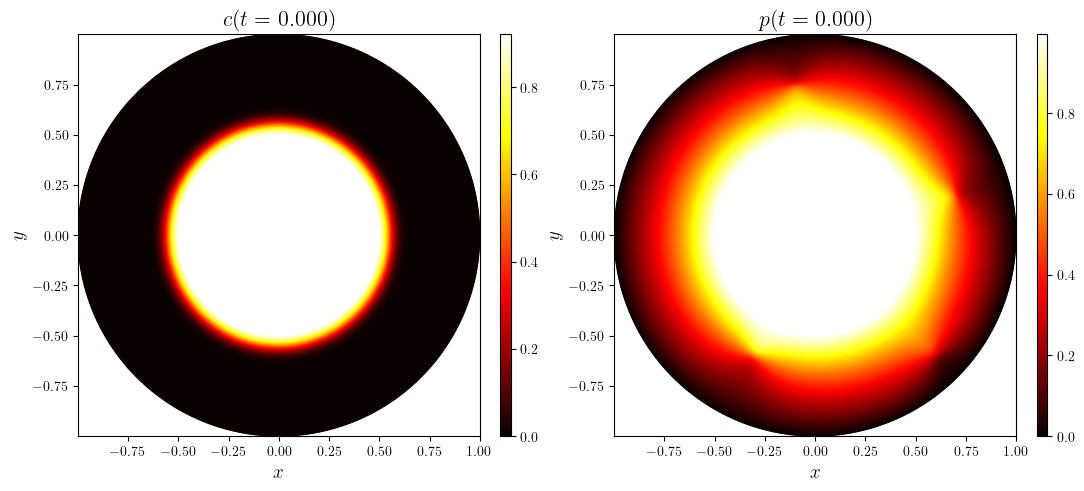

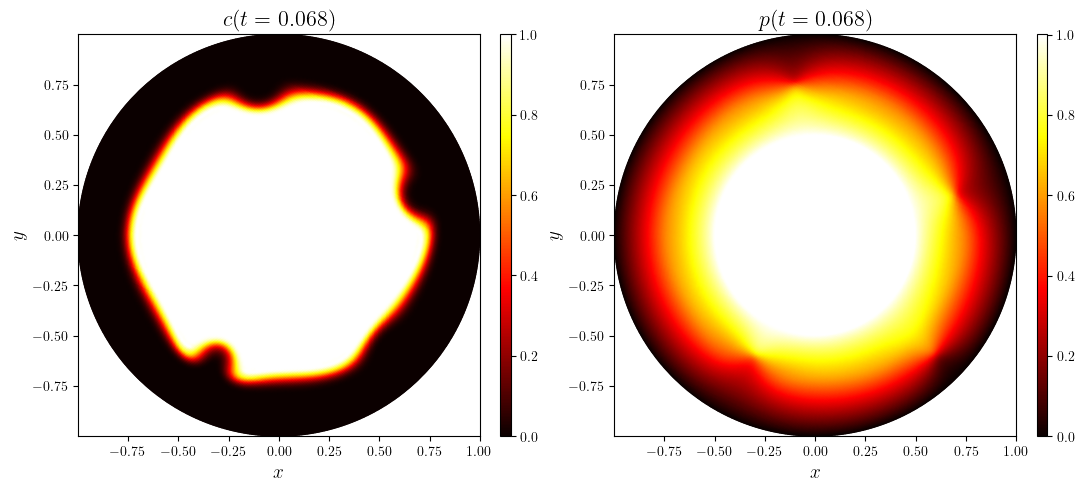

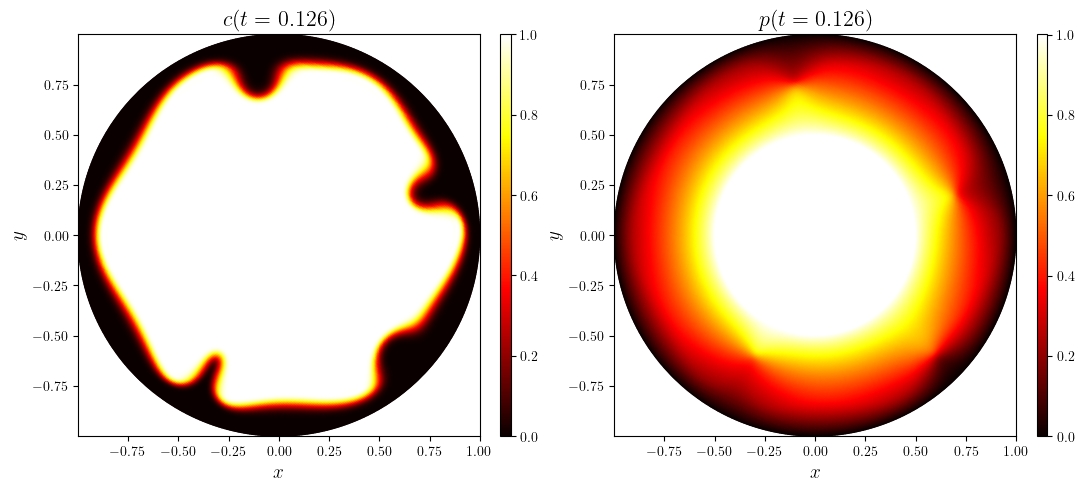

In [6]:
time_indices = (0, int(0.5 * n_stop), -1)
for i in time_indices:
    cp_titles = [f'${w.name}(t={w.time_series[i]:.3f})$' for w in (c, p)]
    mfig, axs, _ = plot_colormap_multifigure(n_cols=2, cbars=True)(
        [w.series[i] for w in (c, p)], 
        cmap='hot',
        title=cp_titles,
    )
    save_figure('_'.join(cp_titles), thumbnail=(i is time_indices[-1]))(mfig)

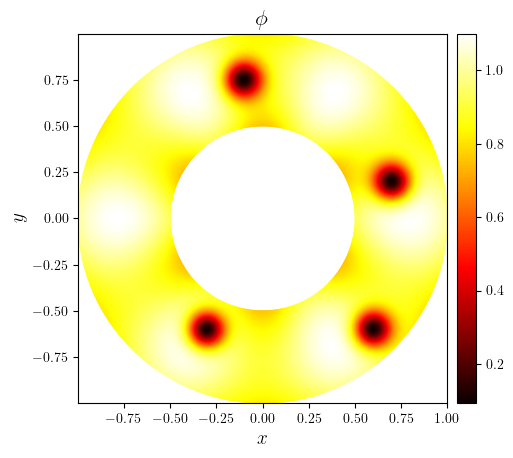

In [8]:
fig, ax = plot_colormap(phi, title='$\phi$')
save_figure('phi(x,y)')(fig)